In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_172 = pd.read_excel('../data/All_GS_172-2.xlsx')
df_j2= pd.read_excel('../data/All-J2ST1.xlsx')
df_j6a=pd.read_excel('../data/All-J6A.xlsx')

In [3]:
df_172= df_172.iloc[:,[0,1,2]]
df_j2= df_j2.iloc[:,[0,1,2]]
df_j6a= df_j6a.iloc[:,[0,1,2]]


In [4]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_172, "GS-172"),
    (df_j2, "J2"),
    (df_j6a, "J6A")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
GS-172       | 5000.00    | 5150.00    | 150.00          | 150     
J2           | 5000.00    | 5150.00    | 150.00          | 150     
J6A          | 5000.00    | 5150.00    | 150.00          | 150     


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [6]:
# Standardize the NPHI for your 3 existing dataframes
nphi_172 = scaler.fit_transform(df_172[['Neutron Porosity']].values).flatten()
nphi_j6a = scaler.fit_transform(df_j6a[['Neutron Porosity']].values).flatten()
nphi_j2 = scaler.fit_transform(df_j2[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_172_j6a = dtw_sakoe_chiba(nphi_172, nphi_j6a, int(0.15 * max(len(nphi_172), len(nphi_j6a))))
dist_nphi_j6a_j2 = dtw_sakoe_chiba(nphi_j6a, nphi_j2, int(0.15 * max(len(nphi_j6a), len(nphi_j2))))
dist_nphi_j2_172 = dtw_sakoe_chiba(nphi_j2, nphi_172, int(0.15 * max(len(nphi_j2), len(nphi_172))))

print(f"NPHI Distance 172-J6a: {dist_nphi_172_j6a:.2f}")
print(f"NPHI Distance J7A-J2: {dist_nphi_j6a_j2:.2f}")
print(f"NPHI Distance J2-172: {dist_nphi_j2_172:.2f}")


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_172= scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j2 = scaler.fit_transform(df_j2[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_172_j6a = dtw_sakoe_chiba(gr_172, gr_j6a, int(0.15 * max(len(gr_172), len(gr_j6a))))

# J6A to J4
dist_gr_j6a_j2 = dtw_sakoe_chiba(gr_j6a, gr_j2, int(0.15 * max(len(gr_j6a), len(gr_j2))))

# J4 to NO159-2
dist_gr_j2_172 = dtw_sakoe_chiba(gr_j2, gr_172, int(0.15 * max(len(gr_j2), len(gr_172))))

print(f"GR Distance 179-J6A: {dist_gr_172_j6a:.2f}")
print(f"GR Distance J6A-J2: {dist_gr_j6a_j2:.2f}")
print(f"GR Distance J2-179: {dist_gr_j2_172:.2f}")

NPHI Distance 172-J6a: 85.62
NPHI Distance J7A-J2: 80.82
NPHI Distance J2-172: 81.85
GR Distance 179-J6A: 90.08
GR Distance J6A-J2: 84.95
GR Distance J2-179: 85.49


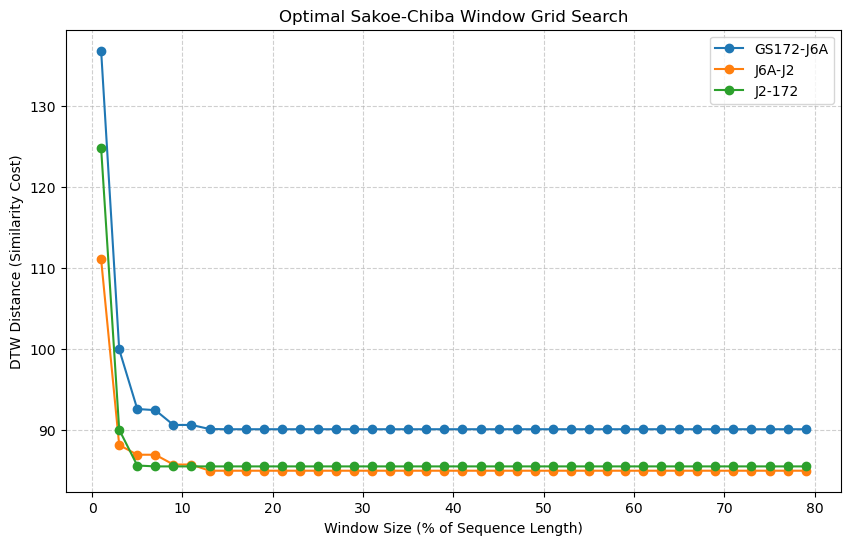

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_172 = scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j2 = scaler.fit_transform(df_j2[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_172, gr_j6a, "GS172-J6A"), (gr_j6a, gr_j2, "J6A-J2"), (gr_j2, gr_172, "J2-172")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

# 4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [8]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)  
    # Find the index of the first time that minimum was reached
    best_index = distance_list.index(min_dist)
    # Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_172_j6a = get_best_window(window_percents.tolist(), all_results["GS172-J6A"])
best_j6a_j2 = get_best_window(window_percents.tolist(), all_results["J6A-J2"])
best_j2_172 = get_best_window(window_percents.tolist(), all_results["J2-172"])

print(f"Optimal Window for 172-J6A: {best_172_j6a}%")
print(f"Optimal Window for J6A-J2: {best_j6a_j2}%")
print(f"Optimal Window for J2-172: {best_j2_172}%")

Optimal Window for 172-J6A: 15%
Optimal Window for J6A-J2: 13%
Optimal Window for J2-172: 7%


In [9]:
# for nphi
# 1. Standardize NPHI Logs
nphi_172 = scaler.fit_transform(df_172[['Neutron Porosity']].values).flatten()
nphi_j6a = scaler.fit_transform(df_j6a[['Neutron Porosity']].values).flatten()
nphi_j2 = scaler.fit_transform(df_j2[['Neutron Porosity']].values).flatten()

# 2. Optimized NPHI Windows from Grid Search
best_nphi_wins = {
    "GS172-J6A": 41,
    "J6A-J2": 45,
    "J2-GS172": 45
}

# 3. Calculate Final Optimized NPHI Distances
dist_nphi_172_j6a = dtw_sakoe_chiba(nphi_172, nphi_j6a, int((best_nphi_wins["GS172-J6A"]/100)*len(nphi_j6a)))
dist_nphi_j6a_j2 = dtw_sakoe_chiba(nphi_j6a, nphi_j2, int((best_nphi_wins["J6A-J2"]/100)*len(nphi_j6a)))
dist_nphi_j2_172 = dtw_sakoe_chiba(nphi_j2, nphi_172, int((best_nphi_wins["J2-GS172"]/100)*len(nphi_j6a)))

print(f"Final Optimized NPHI Distance GS172-J6A: {dist_nphi_172_j6a:.2f}")
print(f"Final Optimized NPHI Distance J6A-J2: {dist_nphi_j6a_j2:.2f}")
print(f"Final Optimized NPHI Distance J2-GS172: {dist_nphi_j2_172:.2f}")

Final Optimized NPHI Distance GS172-J6A: 85.62
Final Optimized NPHI Distance J6A-J2: 80.82
Final Optimized NPHI Distance J2-GS172: 81.85


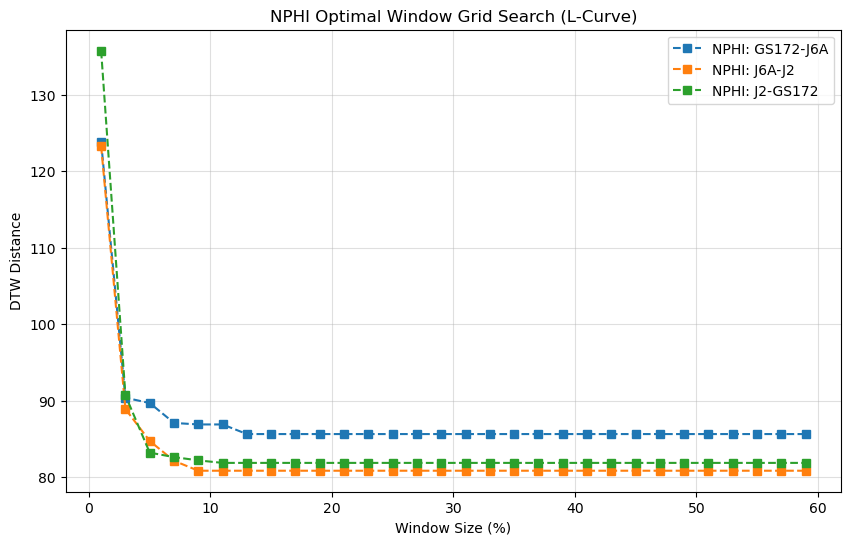

--- Optimized NPHI Windows ---
GS172-J6A: 13%
J6A-J2:    9%
J2-172:  9%


In [10]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_172, nphi_j6a, "GS172-J6A"), 
    (nphi_j6a, nphi_j2, "J6A-J2"), 
    (nphi_j2, nphi_172, "J2-GS172")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_172_j6a = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["GS172-J6A"])
best_nphi_j6a_j2 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J6A-J2"])
best_nphi_j2_172 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J2-GS172"])

print(f"--- Optimized NPHI Windows ---")
print(f"GS172-J6A: {best_nphi_172_j6a}%")
print(f"J6A-J2:    {best_nphi_j6a_j2}%")
print(f"J2-172:  {best_nphi_j2_172}%")

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,
    "axes.titlesize": 34,
    "legend.fontsize": 30,
    "figure.figsize": (18, 18),
    "axes.linewidth": 2.0
})
def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [12]:
gr_range = np.arange(1, 80, 2)

# Plotting GS172-2 vs J6A
#plot_well_optimization(gr_range, all_results["GS172-J6A"], "GS172-2 vs J6A", "Gamma Ray")

# Plotting J6A vs J2ST1
#plot_well_optimization(gr_range, all_results["J6A-J2"], "J6A vs J2ST1", "Gamma Ray")

# Plotting J2ST1 vs GS172-2
#plot_well_optimization(gr_range, all_results["J2-172"], "J2ST1 vs GS172-2", "Gamma Ray")


In [13]:
# 2. NPHI Plots (1% - 59% Range)
nphi_range = np.arange(1, 61, 2)

# Plotting GS172-2 vs J6A
#plot_well_optimization(nphi_range, nphi_grid_results["GS172-J6A"], "GS172-2 vs J6A", "NPHI")

# Plotting J6A vs J2ST1
#plot_well_optimization(nphi_range, nphi_grid_results["J6A-J2"], "J6A vs J2ST1", "NPHI")

# Plotting J2ST1 vs GS172-2
#plot_well_optimization(nphi_range, nphi_grid_results["J2-GS172"], "J2ST1 vs GS172-2", "NPHI")

## Correlation plots 

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Zone definitions from your provided data
zones_j6a= {
    'Asl Marl': (5000, 5045, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5045, 5095, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5095, 5130, '#d9ead3')   # Light Green
}

zones_j2st1= {
    'Asl Marl': (5000, 5042, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5042, 5092, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5092, 5130, '#d9ead3')   # Light Green
}

# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [16]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_j6a, zones_j2st1], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [17]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

## FINAL PLOT


Matched GR L-Curve saved: L_curve/J6A vs J2ST1_GR_Lcurve_Matched.jpg


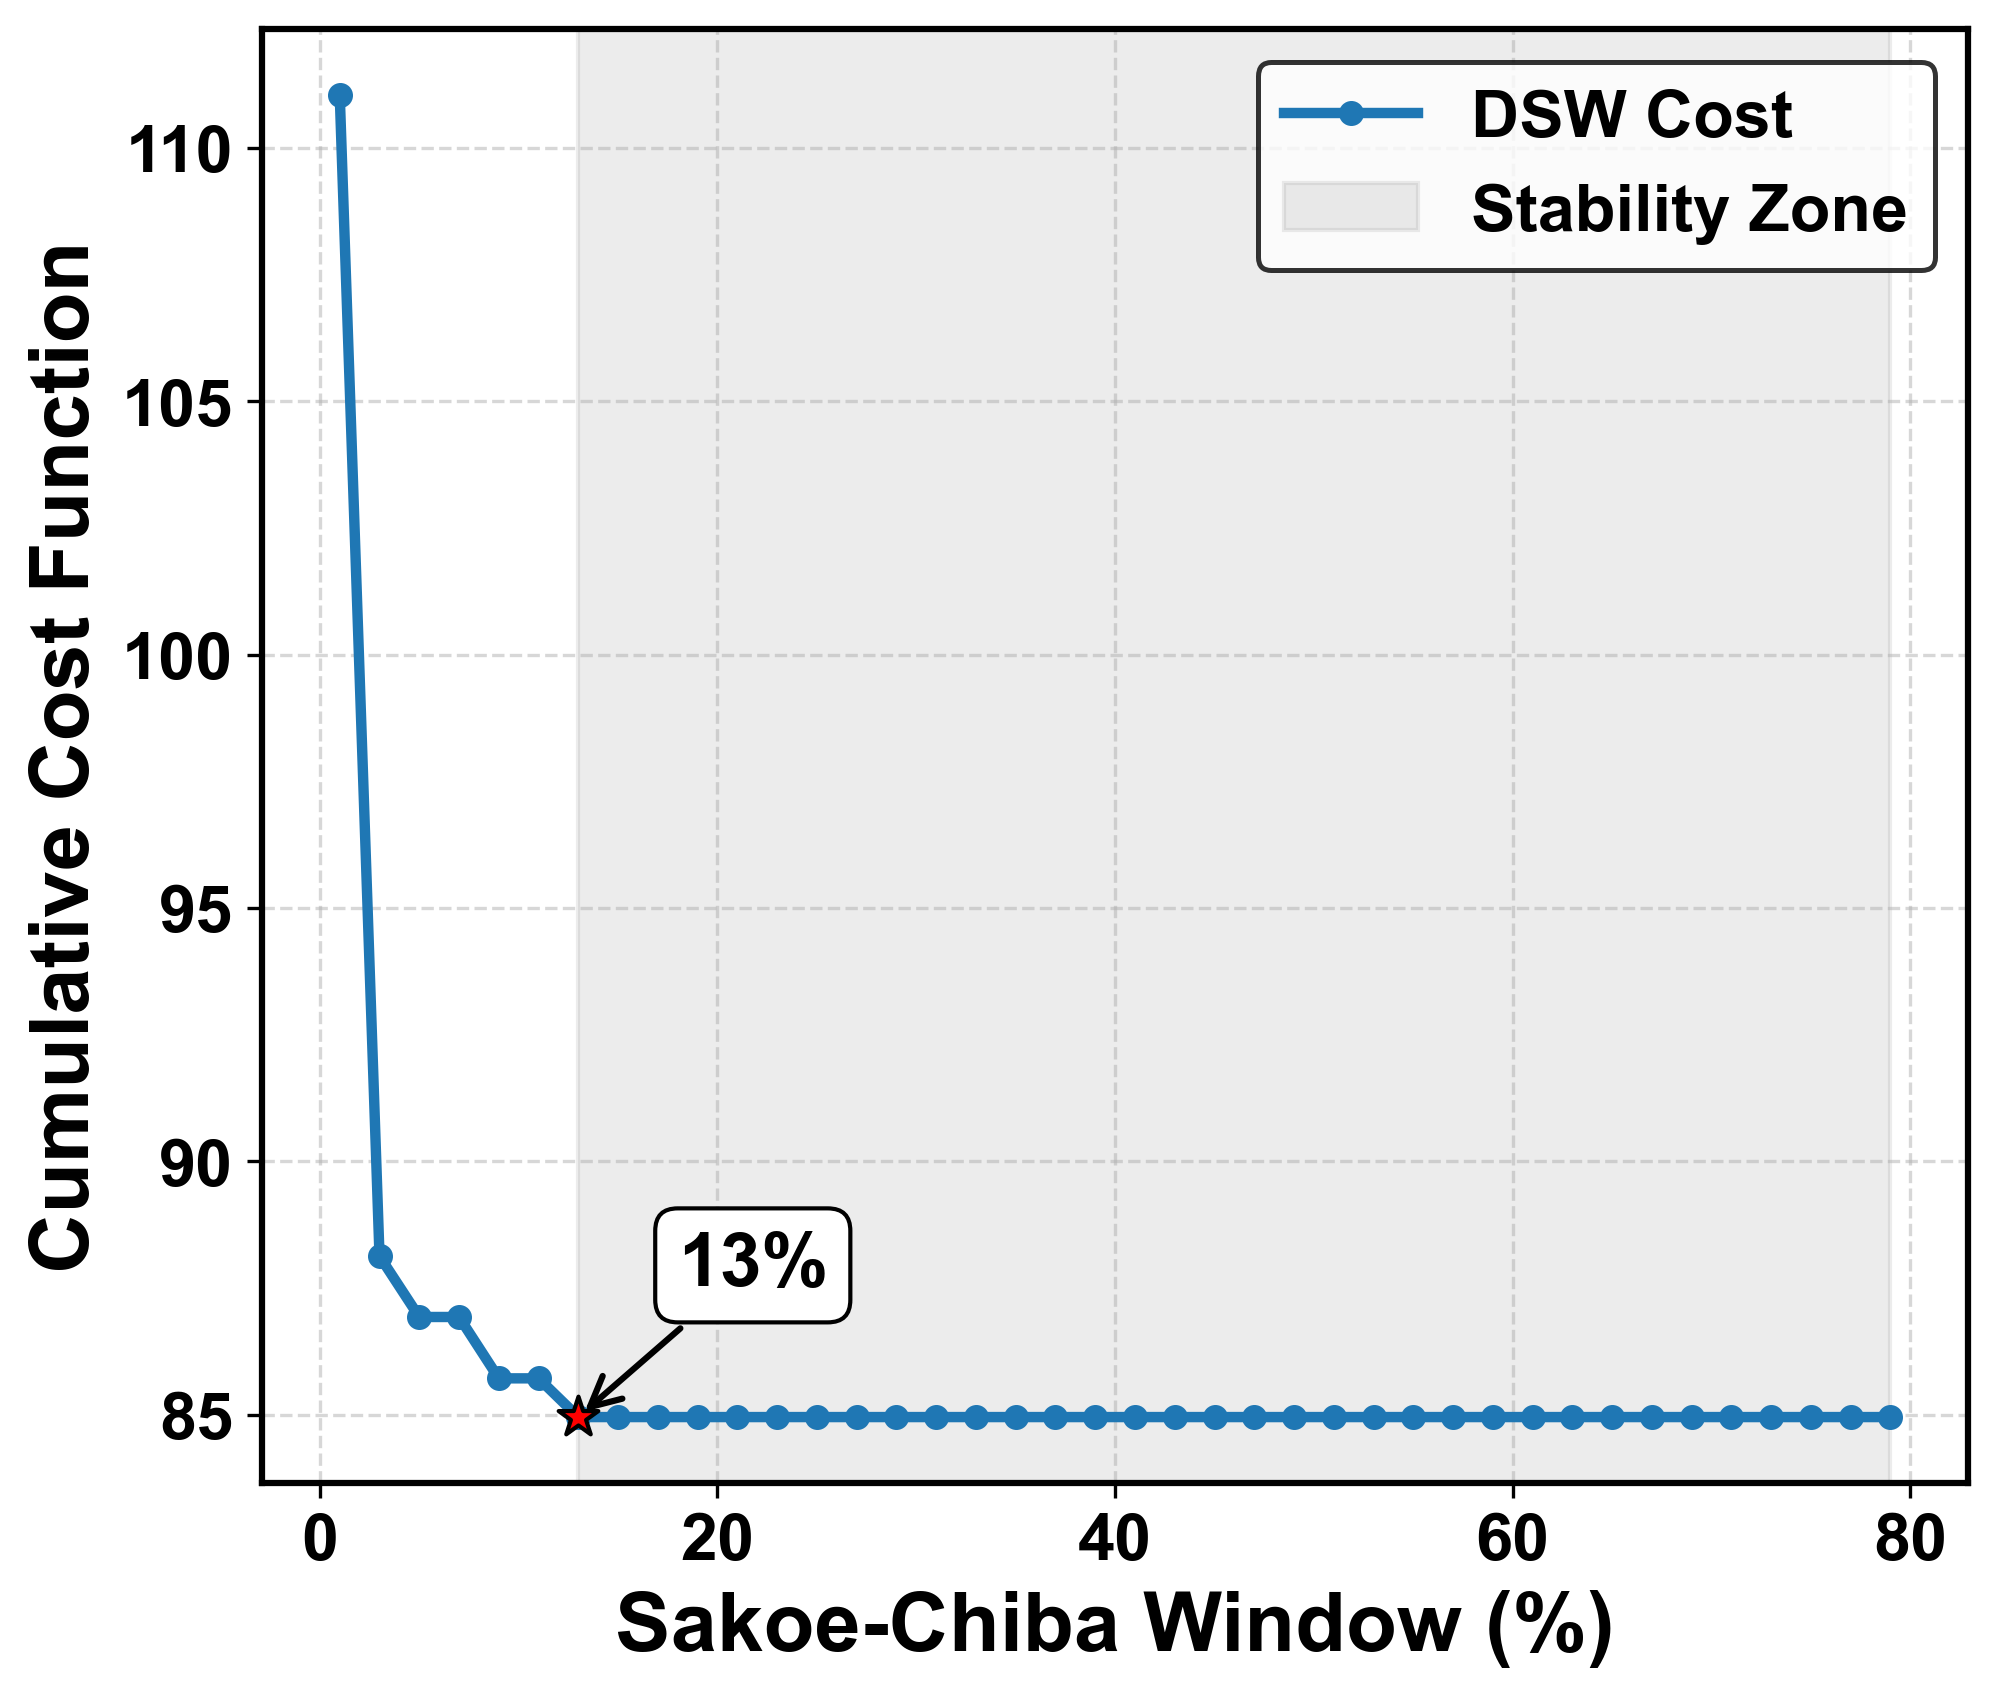

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. MATCHING GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_well_optimization_matched(percents, distances, well_pair, log_type):
    if not os.path.exists('L_curve'): 
        os.makedirs('L_curve')
    
    percents_list = list(percents)
    dist_list = list(distances)
    
    # Automatic Optimum Detection
    min_dist = min(dist_list)
    opt_idx = dist_list.index(min_dist)
    opt_window = percents_list[opt_idx]
    
    # 2. MATCHING FIGURE SIZE (7x6)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Plot Data (Blue #1f77b4 with circle markers 'o')
    ax.plot(percents_list, dist_list, color='#1f77b4', lw=2.5, 
            marker='o', ms=5, label='DSW Cost')
    
    # Stability Zone
    ax.axvspan(opt_window, max(percents_list), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimal Point (Red Star)
    ax.scatter(opt_window, min_dist, color='red', edgecolor='black', 
               s=100, marker='*', zorder=10)

    # 3. MATCHING ANNOTATION (Simple bold percentage)
    # Proportional offset for the text position
    y_range = max(dist_list) - min_dist
    ax.annotate(f'{int(opt_window)}%',
                xy=(opt_window, min_dist),
                xytext=(opt_window + 5, min_dist + (y_range * 0.1)),
                fontsize=18,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # 4. BORDERS & TICKS
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("Cumulative Cost Function")

    # Bolding the axis ticks
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # 5. CLEAN LEGEND
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)
    for text in leg.get_texts():
        text.set_fontweight('bold')

    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    # Save (matching naming convention)
    save_path = f"L_curve/{well_pair}_GR_Lcurve_Matched.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    
    print(f"Matched GR L-Curve saved: {save_path}")
    plt.show()

# --- EXECUTION ---
gr_range = np.arange(1, 80, 2)
# Using the specific result for J6A vs J2ST1
plot_well_optimization_matched(gr_range, all_results["J6A-J2"], "J6A vs J2ST1", "Gamma Ray")

Full Matrix Plot saved: L_curve/J2ST1_J6A_Full_Matrix_GR.jpg


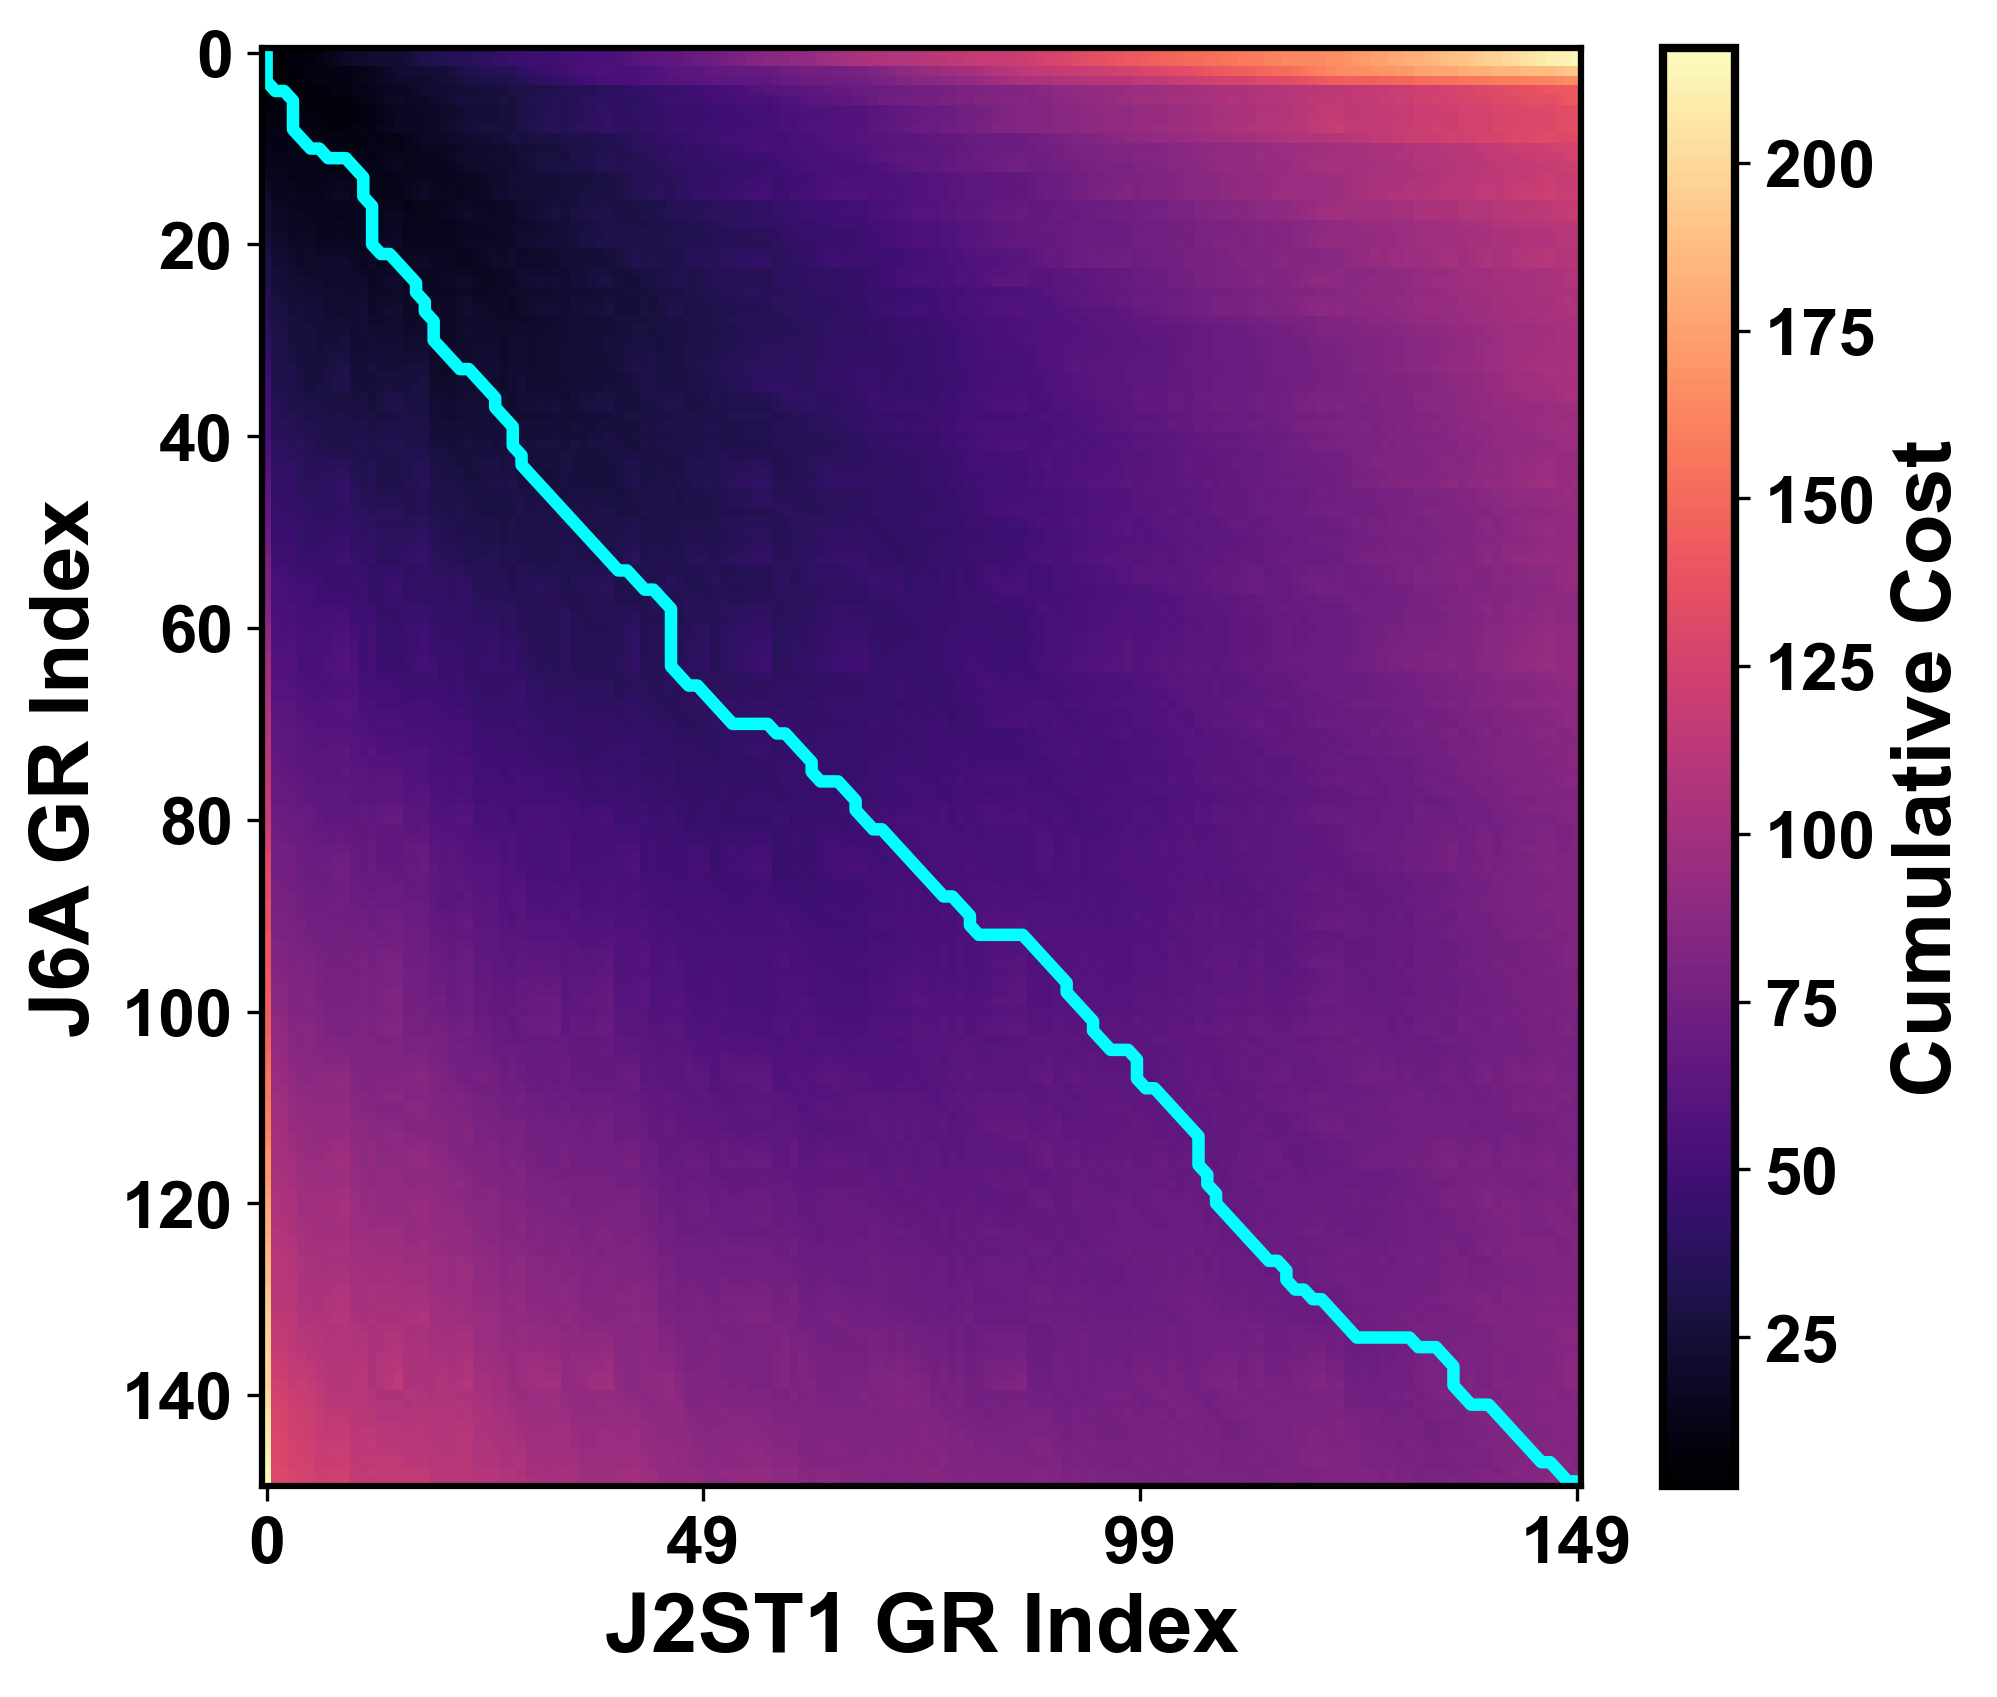

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300
})

def plot_full_warping_matrix(df1, df2, label1, label2):
    # Standardize logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. Compute FULL Cumulative Cost Matrix (No Window)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):  # Full range search
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 3. Backtrack for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION (Full Grid)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Plotting the full matrix without masking
    full_matrix = dtw_matrix[1:, 1:]
    img = ax.imshow(full_matrix.T, origin='upper', cmap='magma', aspect='auto')
    
    # Optimal Path
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)
    
    # Labels
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")
    
    # Ticks matching your publication style
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontweight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()

    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_Full_Matrix_GR.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    
    print(f"Full Matrix Plot saved: {save_path}")
    plt.show()

# --- EXECUTE ---
plot_full_warping_matrix(df_j2, df_j6a, "J2ST1", "J6A")

Matched GR Correlation Plot saved: L_curve/J6A_J2ST1_GR_Correlation_Matched.jpg


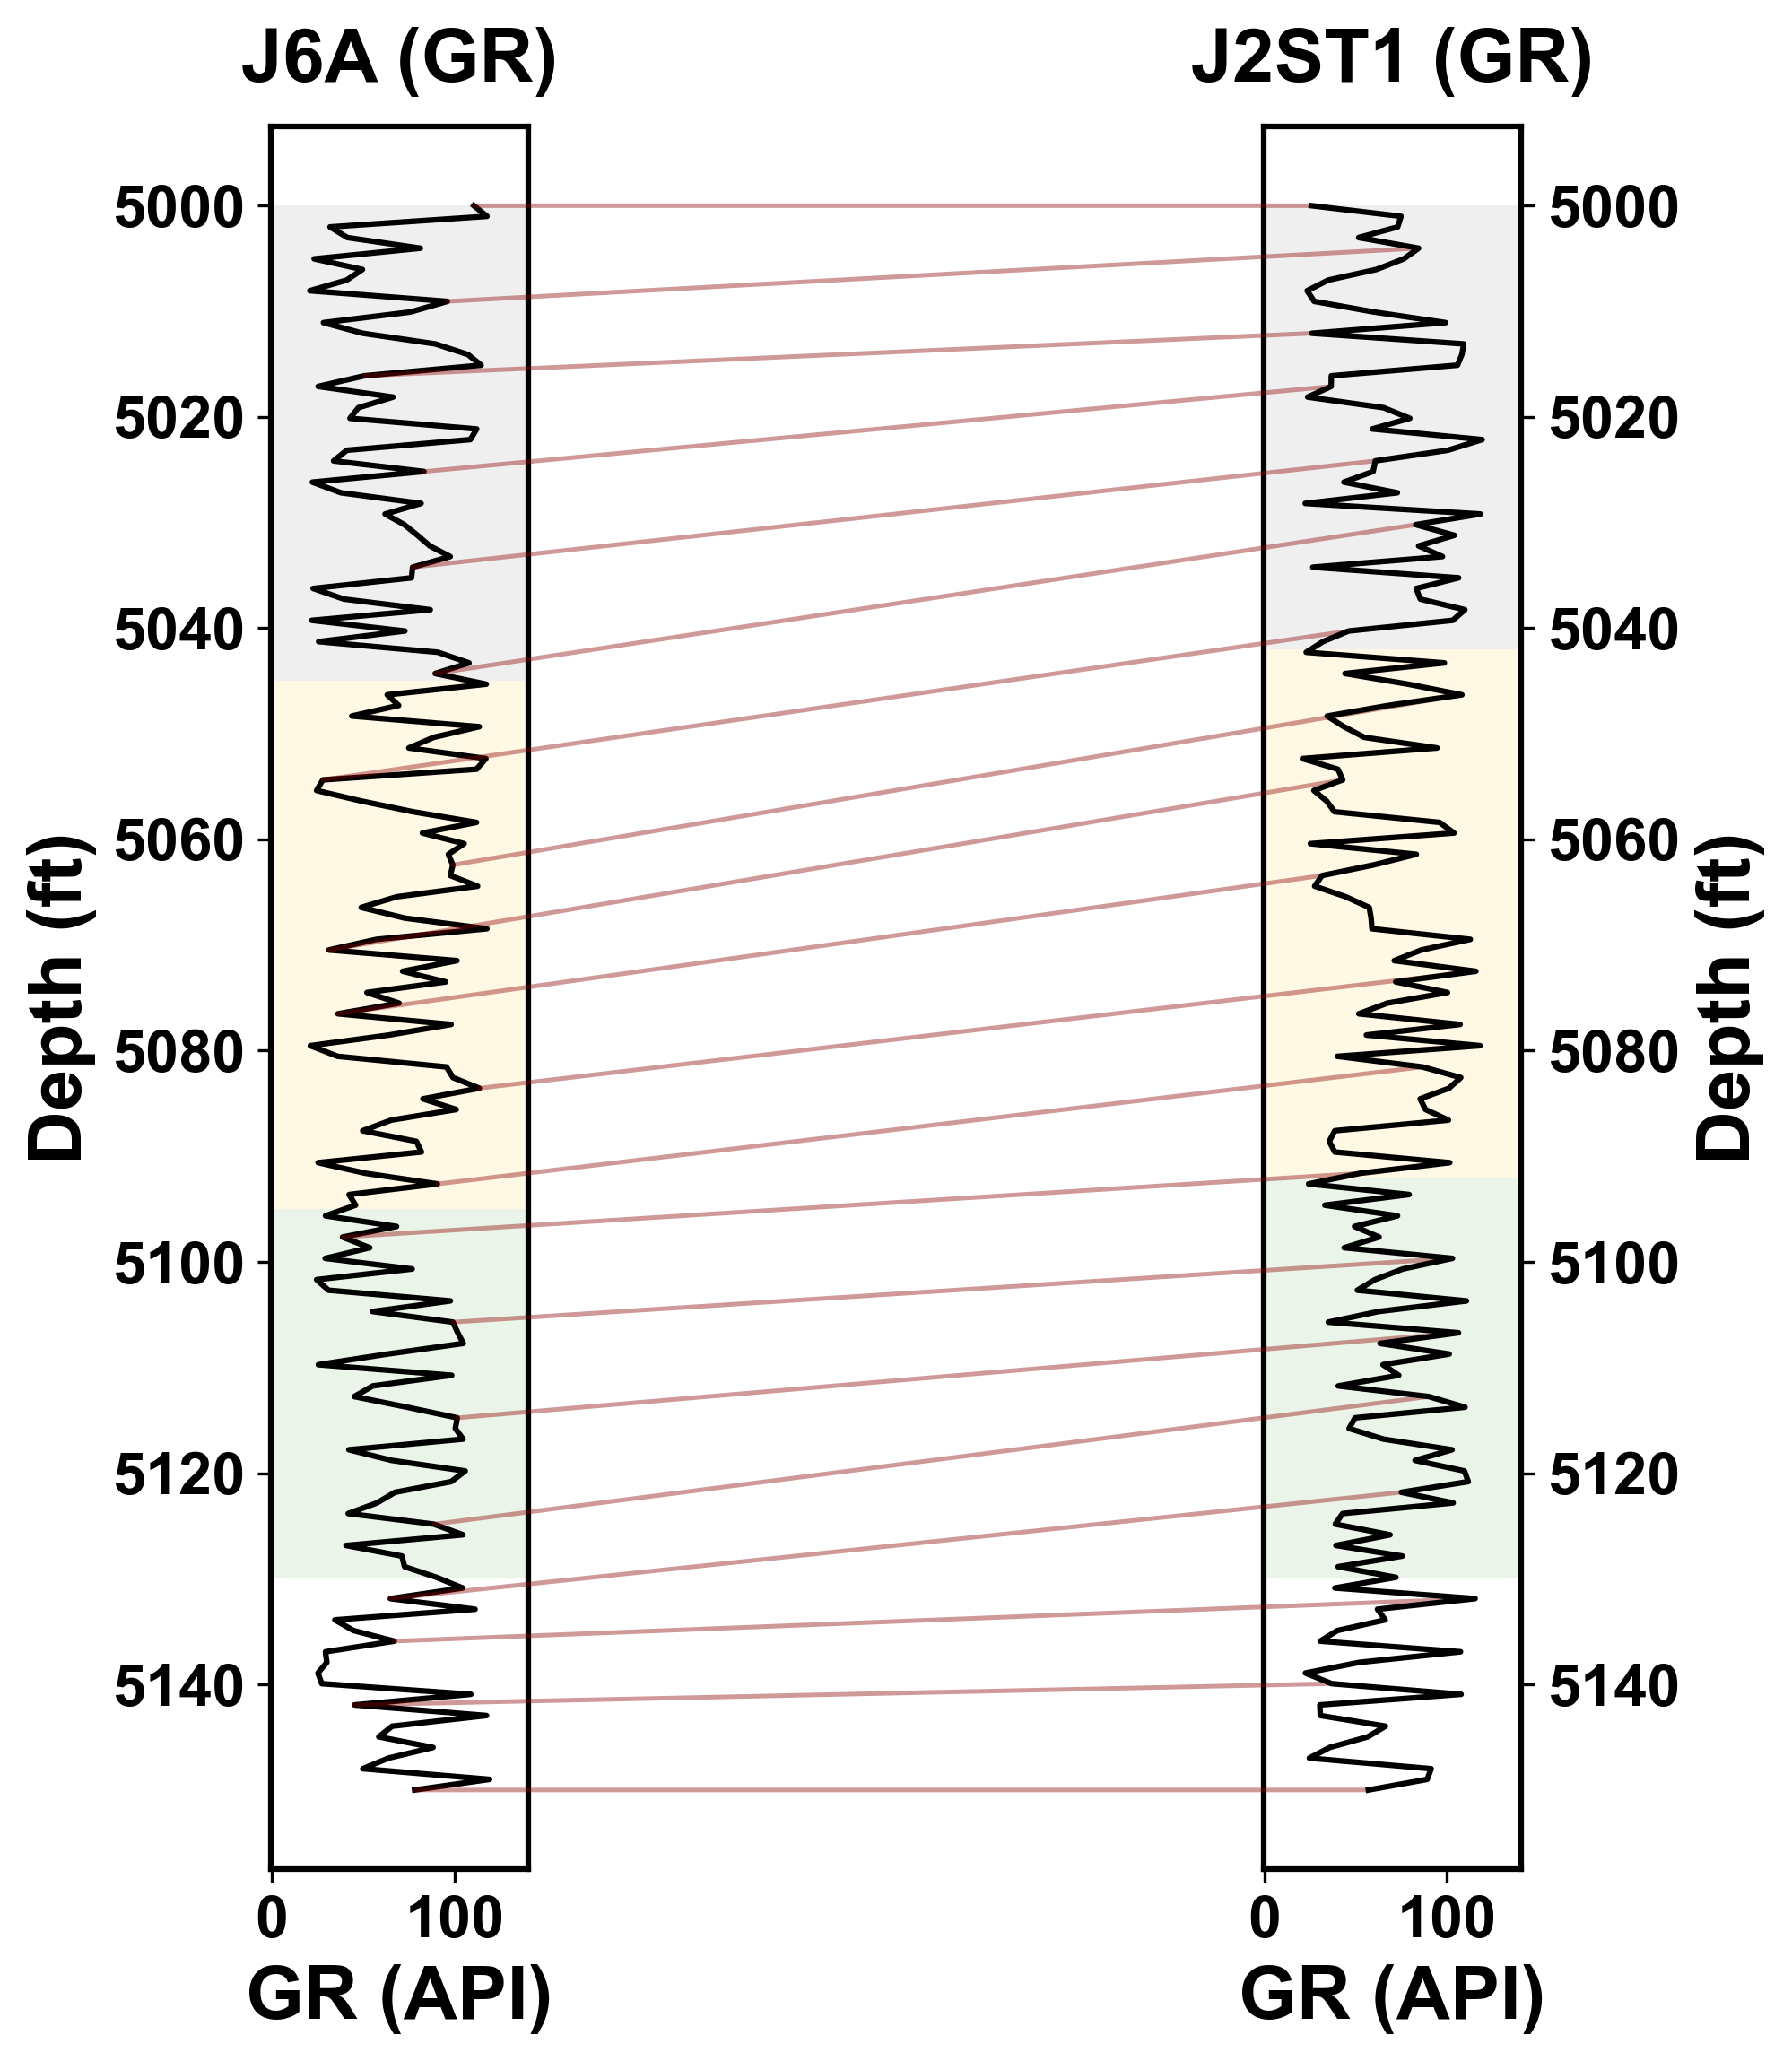

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
import os

# 1. MATCHING GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_gr_correlation_matched(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize GR logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    # 2. Get DTW path
    path = dtw_with_path(s1, s2, window_p)
    
    # 3. MATCHING FIGURE SIZE (7x8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # LOG LINE (Black, matched weight)
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12)
        ax.set_xlabel("GR (API)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # BOLD TICKS
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (FIXED: Using facecolor to remove warning)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # MATCHING WELL BOX WIDTH (The widening fix)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Borders
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
            
        ax.grid(False)

    # 4. CORRELATION LINES (Dark Red, matched density)
    # --- FIX 2: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10  
    for k in range(0, len(path), line_density_step):
        i1, i2 = path[k]
        y1, x1 = df1.iloc[i1, 0], df1.iloc[i1, 1]
        y2, x2 = df2.iloc[i2, 0], df2.iloc[i2, 1]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    # Clean layout
    plt.tight_layout()
    
    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_GR_Correlation_Matched.jpg"
    plt.savefig(save_path, bbox_inches='tight')

    print(f"Matched GR Correlation Plot saved: {save_path}")
    plt.show()

# --- EXECUTE ---
# --- FIX 3: Passed the dummy zone parameters to overlay your validation logs correctly ---
plot_gr_correlation_matched(df_j6a, df_j2, zones_j6a ,zones_j2st1, "J6A", "J2ST1", 0.13)

## For NPHI

Refined NPHI L-Curve saved: L_curve/J6A vs J2ST1_NPHI_Lcurve_RefinedArrow.jpg


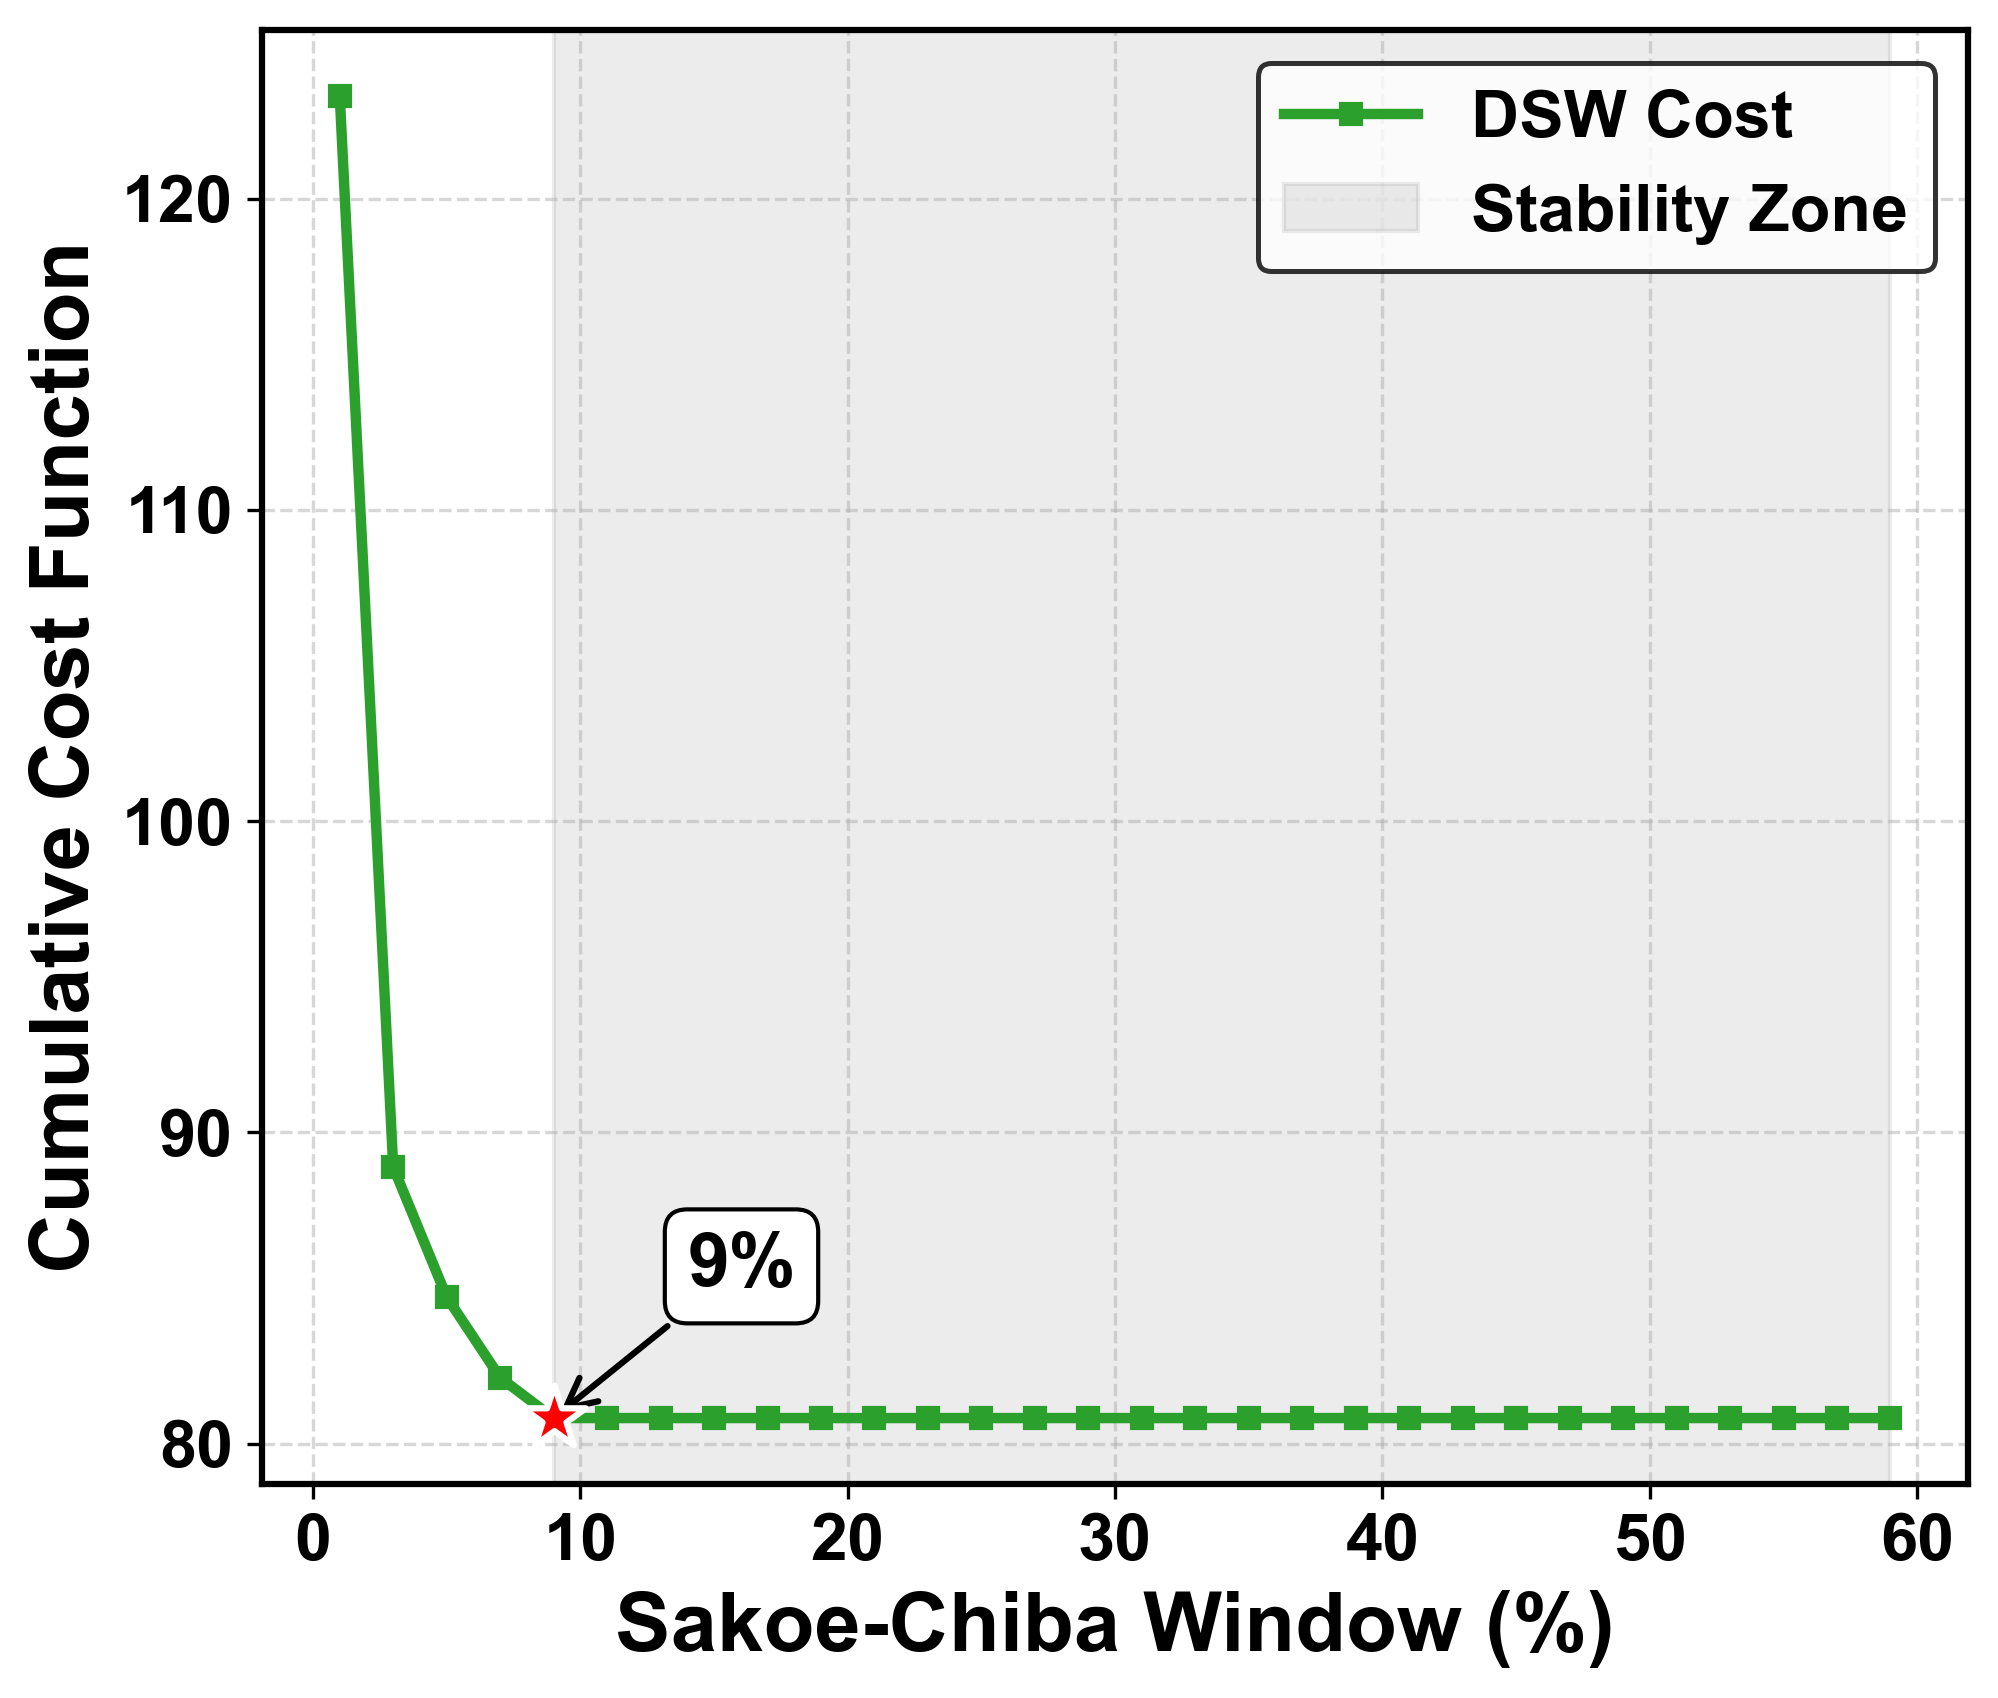

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. GLOBAL STYLE (Arial + Compact Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_optimization_refined_arrow(percents, distances, well_pair, log_type):
    if not os.path.exists('L_curve'): 
        os.makedirs('L_curve')
    
    percents_list = list(percents)
    dist_list = list(distances)
    
    # Optimum Detection
    min_dist = min(dist_list)
    opt_idx = dist_list.index(min_dist)
    opt_window = percents_list[opt_idx]
    
    # FIGURE SIZE (7x6)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Plot Data (Green with square markers)
    ax.plot(percents_list, dist_list, color='#2ca02c', lw=2.5, 
            marker='s', ms=5, label='DSW Cost')
    
    # Stability Zone
    ax.axvspan(opt_window, max(percents_list), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimal Point (Red Star)
    ax.scatter(opt_window, min_dist, color='red', edgecolor='white', 
               linewidth=1.5, s=250, marker='*', zorder=20)

    # 2. Refined Annotation logic for short arrow
    # Use a small proportion (e.g., 5-10%) of the y-range as the vertical offset
    y_range = max(dist_list) - min_dist
    refined_y_text = min_dist + (y_range * 0.10)  # Proportional offset

    ax.annotate(f'{int(opt_window)}%',
                xy=(opt_window, min_dist),
                xytext=(opt_window + 5, refined_y_text),
                fontsize=18,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # Borders & Labels
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("Cumulative Cost Function")

    # Bolding the axis ticks
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Legend
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)
    for text in leg.get_texts():
        text.set_fontweight('bold')

    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    # Save
    save_path = f"L_curve/{well_pair}_NPHI_Lcurve_RefinedArrow.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    
    print(f"Refined NPHI L-Curve saved: {save_path}")
    plt.show()

# --- EXECUTION ---
nphi_range = np.arange(1, 61, 2)
# Using your grid results dictionary
plot_nphi_optimization_refined_arrow(nphi_range, nphi_grid_results["J6A-J2"], "J6A vs J2ST1", "NPHI")

Full NPHI Matrix saved: L_curve/J2ST1_J6A_NPHI_Full_Warping.jpg


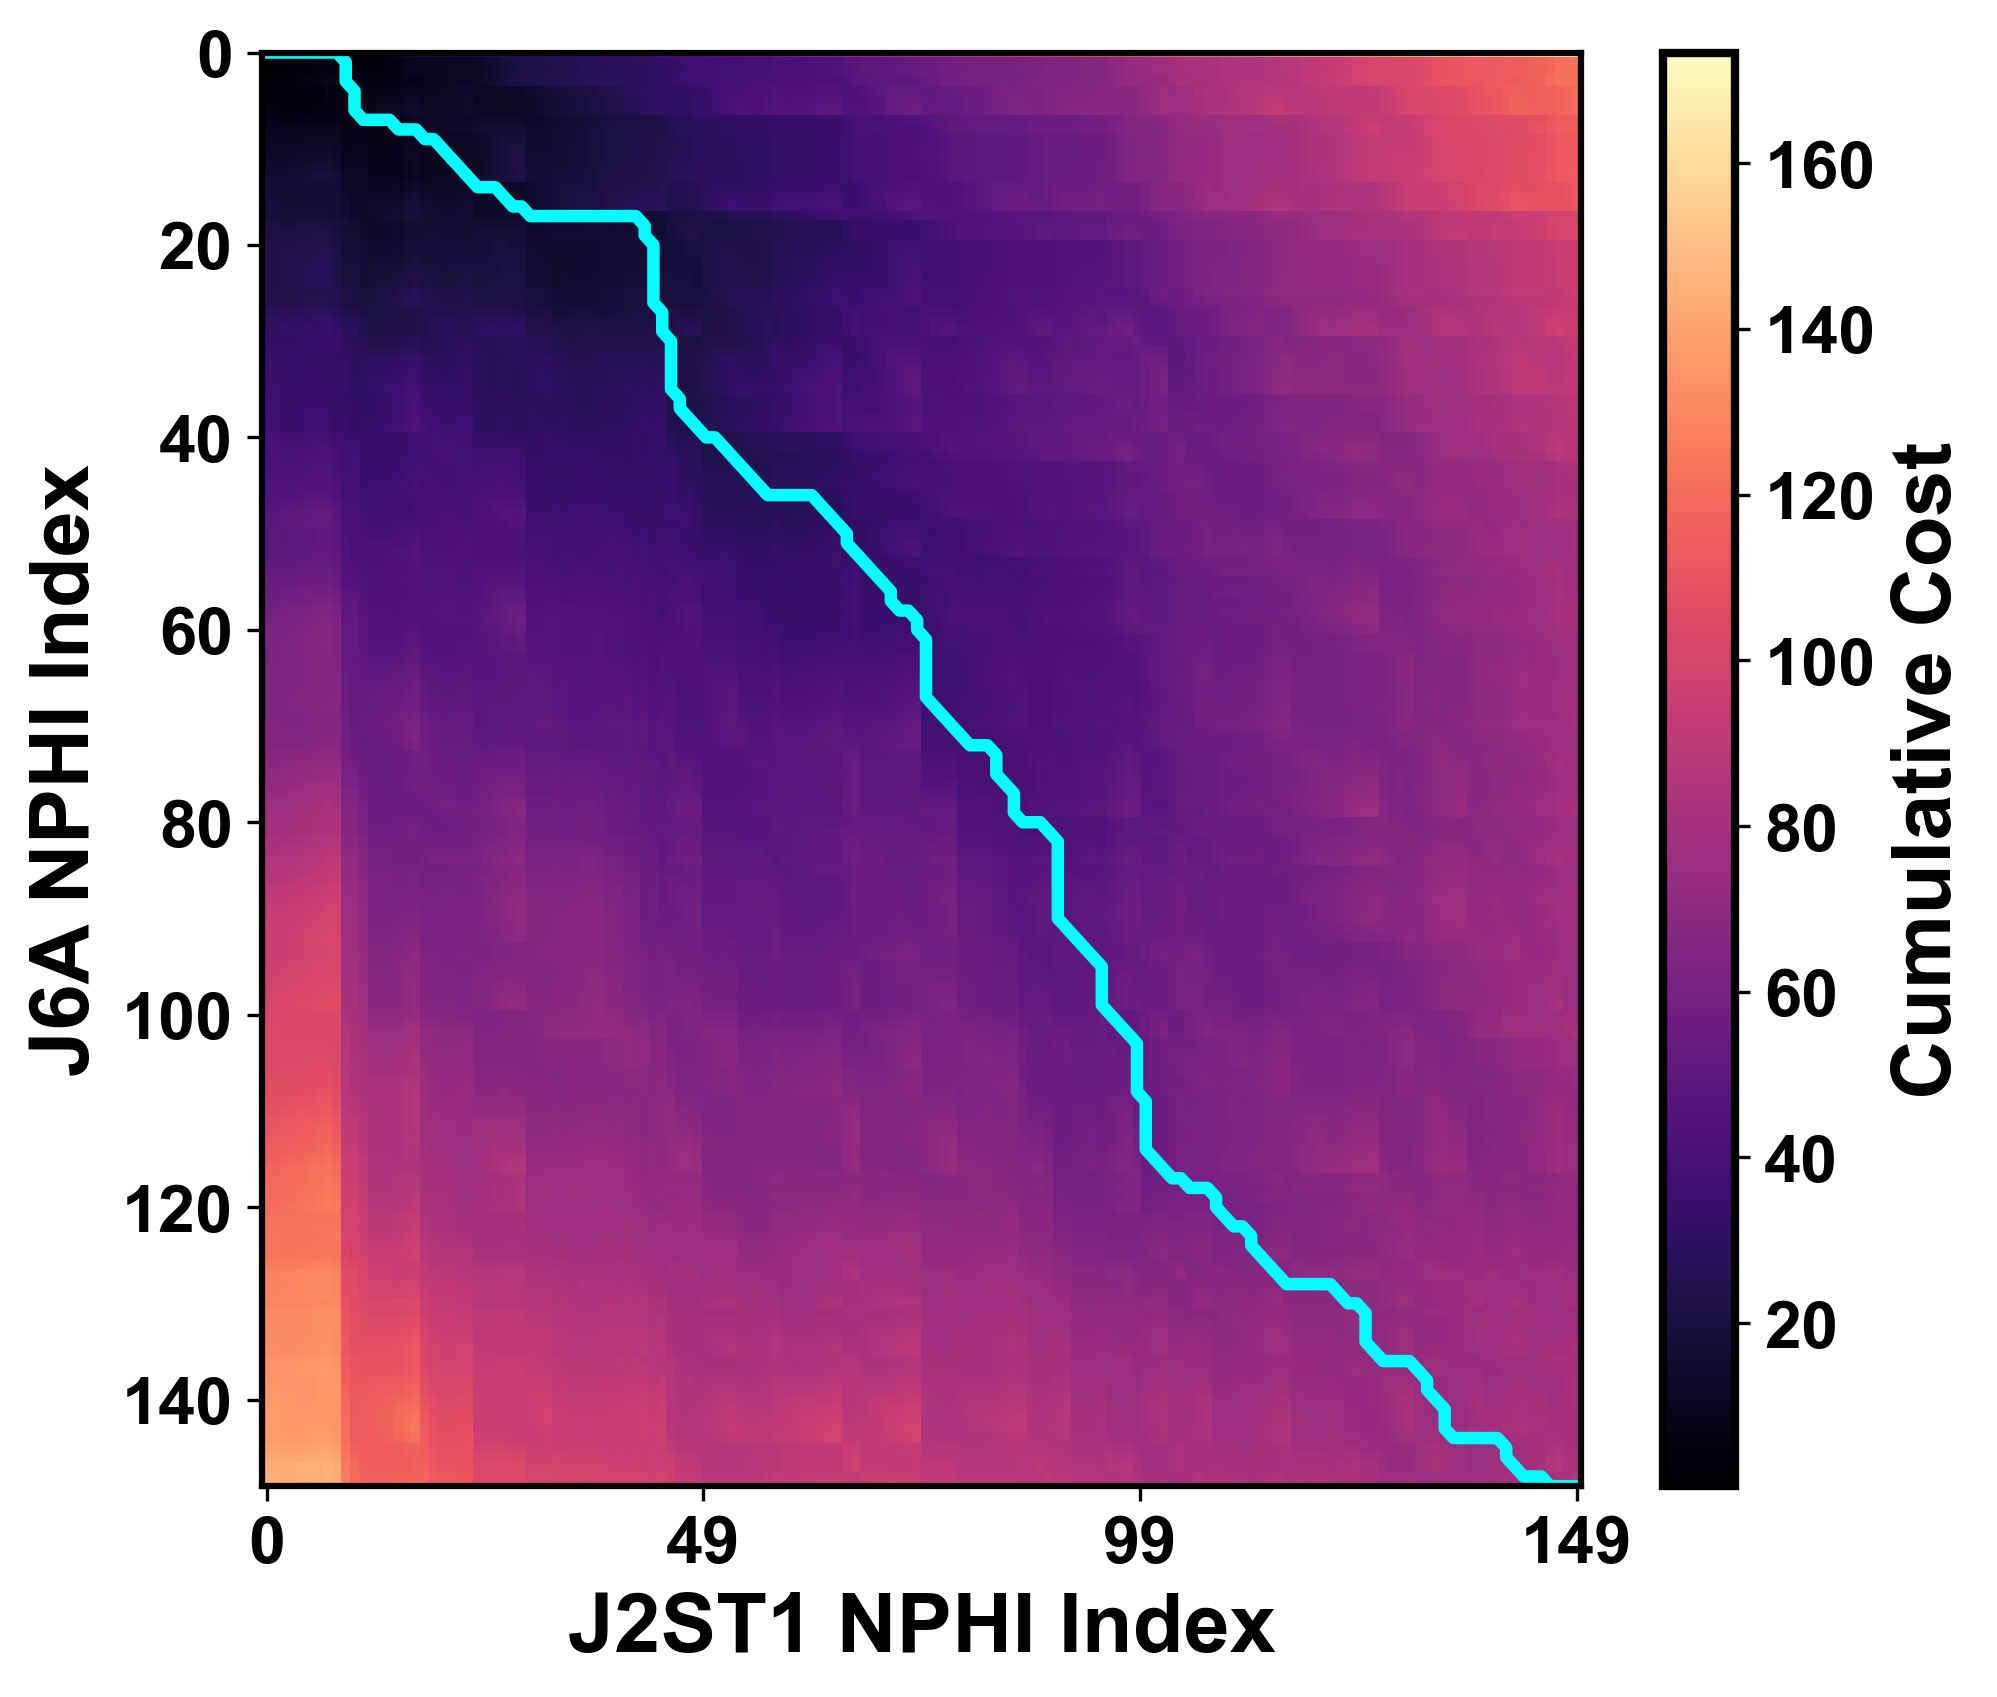

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
import os

# 1. MATCHING GLOBAL STYLE (Arial + Publication Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_full_warping_matched(df1, df2, label1, label2):
    # Standardize NPHI logs (Index 2) + light median filter for stability
    scaler = StandardScaler()
    s1_raw = df1.iloc[:, 2].values
    s2_raw = df2.iloc[:, 2].values
    
    s1 = scaler.fit_transform(medfilt(s1_raw, 3).reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(medfilt(s2_raw, 3).reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. Compute FULL Cumulative Cost Matrix (No Window)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 3. Backtrack for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION (7x6 Size)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    full_matrix = dtw_matrix[1:, 1:]
    img = ax.imshow(full_matrix.T, origin='upper', cmap='magma', aspect='auto')
    
    # Optimal Path (cyan)
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)
    
    # 5. LABELS & AXIS FIXES
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")
    
    # Clip y-axis to avoid negative ticks
    ax.set_ylim(m - 1, 0) 
    
    # Tick density (4 ticks)
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontweight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()

    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Full_Warping.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    
    print(f"Full NPHI Matrix saved: {save_path}")
    plt.show()

# --- EXECUTE FULL ---
plot_nphi_full_warping_matched(df_j2, df_j6a, "J2ST1", "J6A")

Matched NPHI Correlation Plot saved: L_curve/J6A_J2ST1_NPHI_Correlation_Matched.jpg


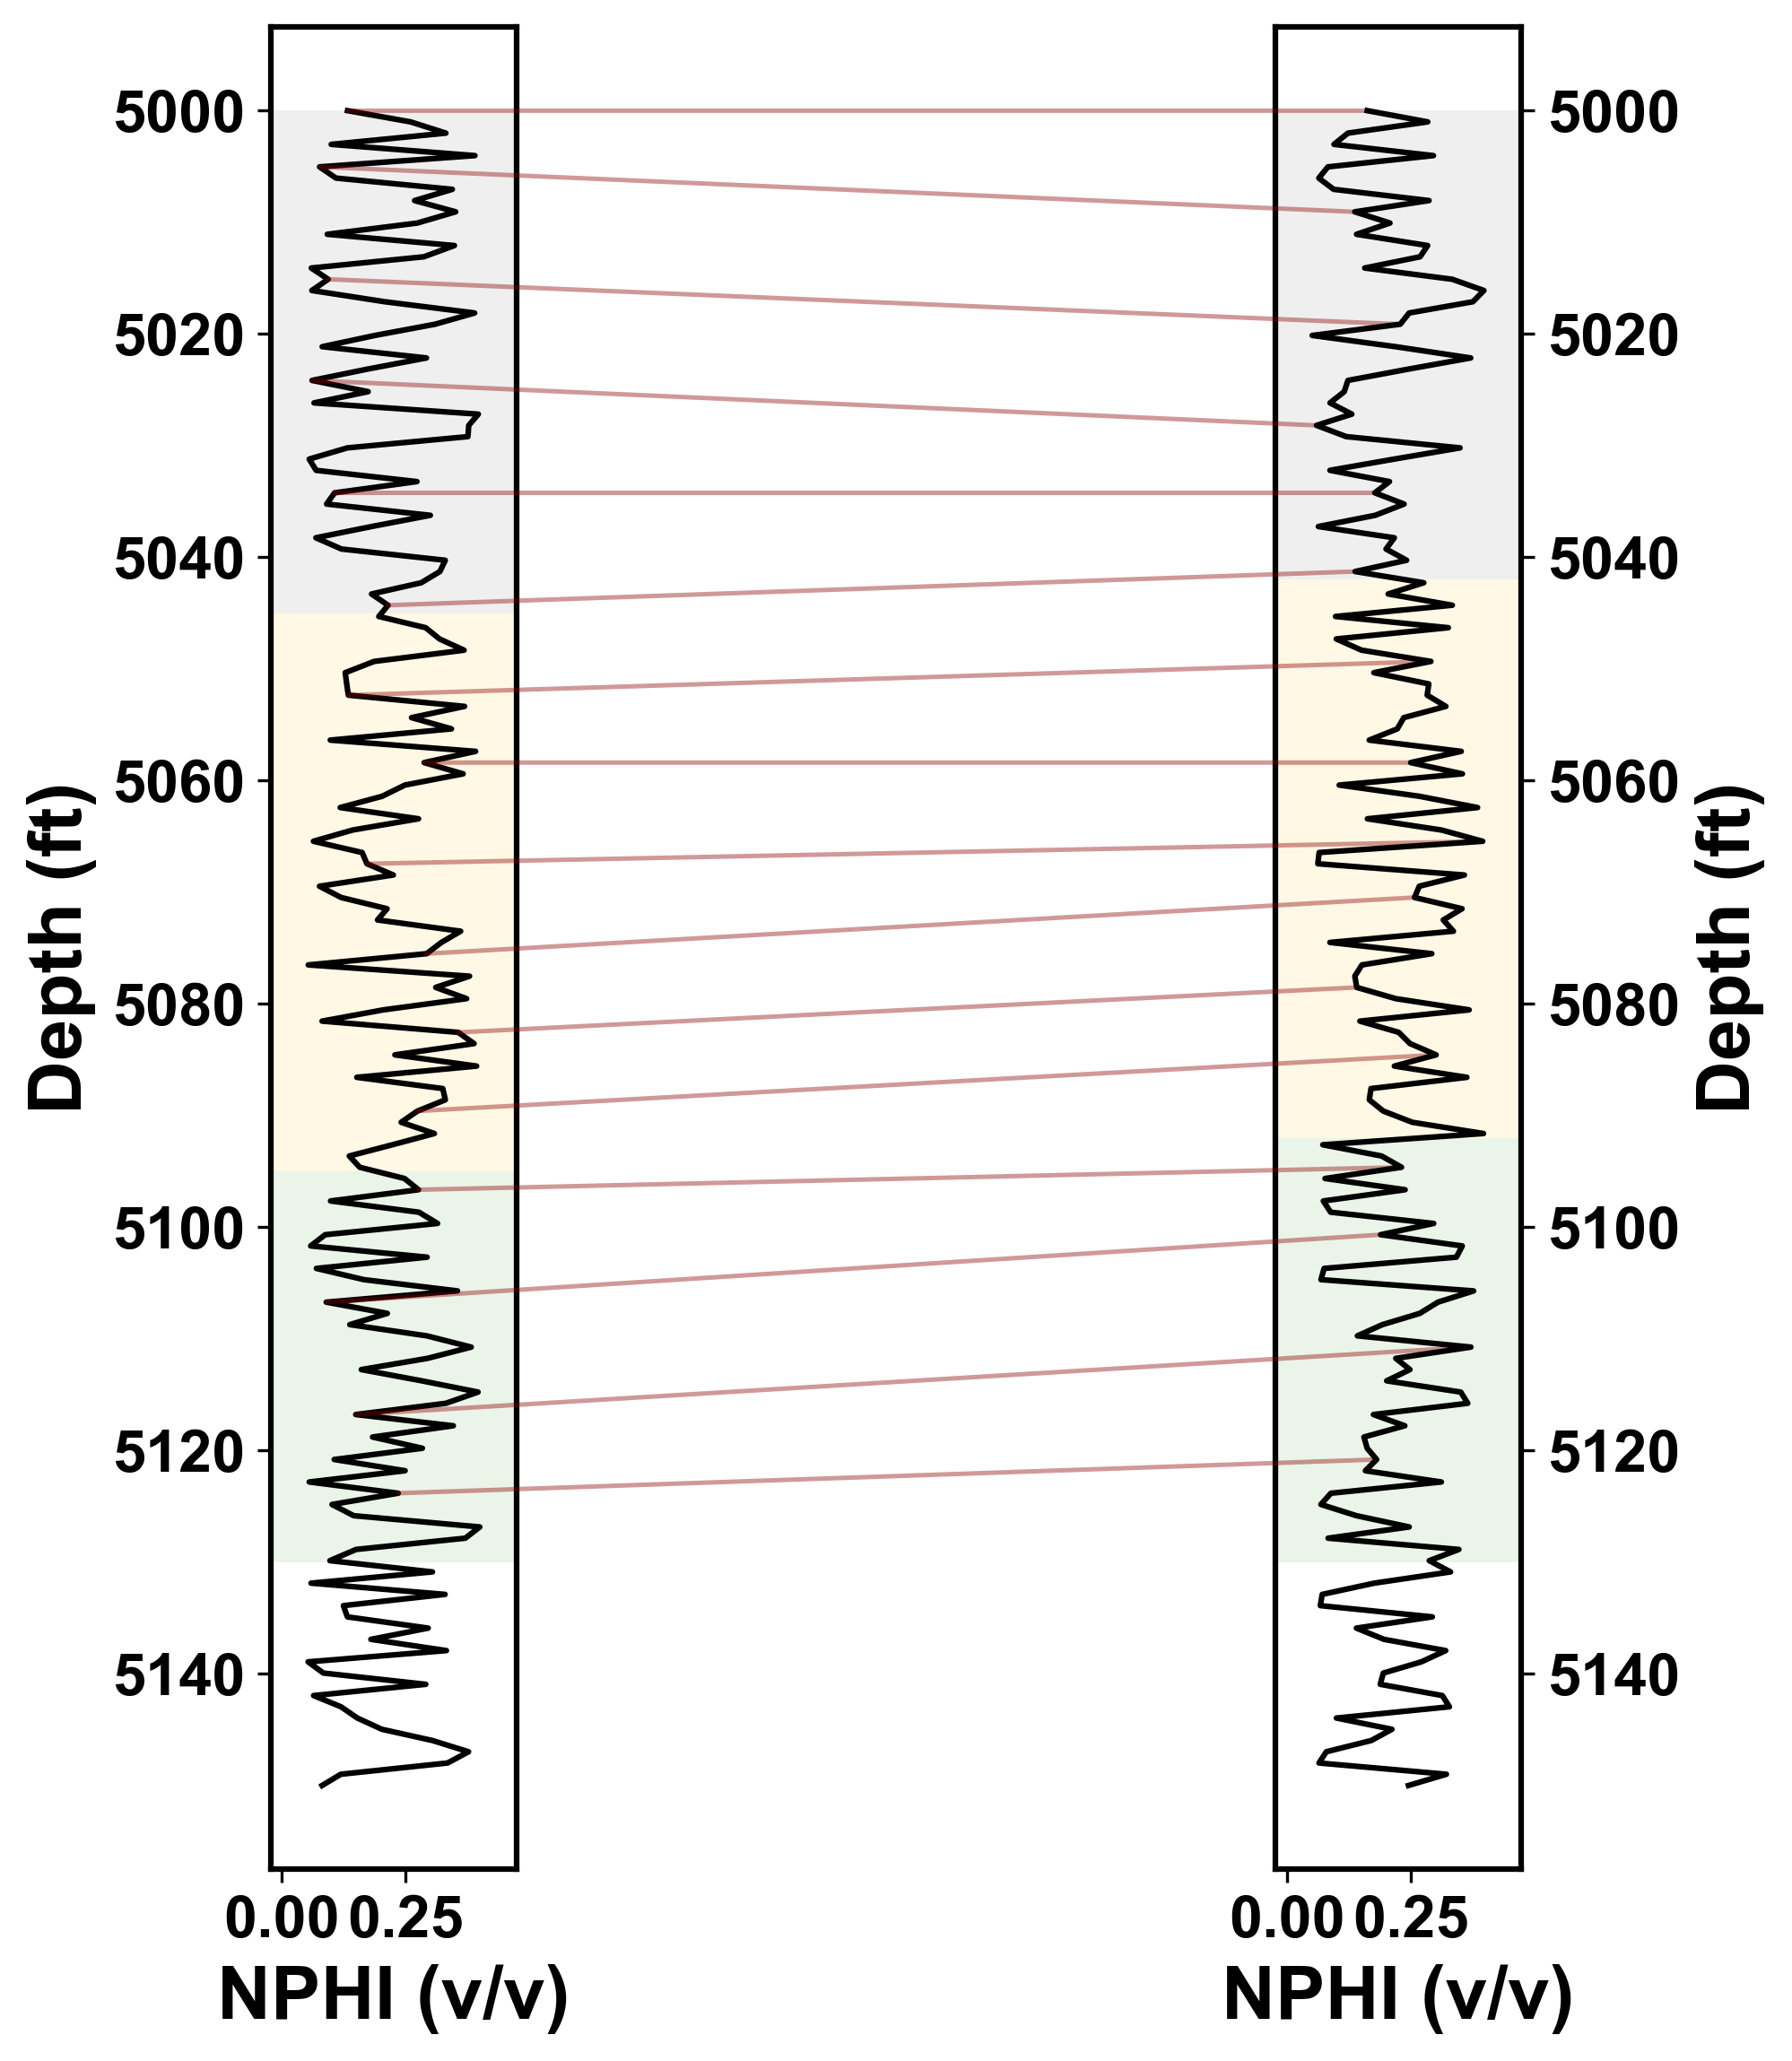

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
import os

# 1. MATCHING GLOBAL STYLE (Arial + Compact Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_correlation_matched(df1, df2, zones1, zones2, label1, label2, window_p):
    # 2. MATCHING FIGURE SIZE (7x8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))
    
    # 3. Standard Well Plotting
    for i, (df, zones) in enumerate([(df1, zones1), (df2, zones2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2] # Neutron Porosity Index

        # Log Line
        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # BOLD TICKS
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (FIXED: Using facecolor to remove matplotlib warning)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # MATCHING WELL BOX WIDTH (The widening fix from code 1)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Borders
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

    # 4. PIECEWISE CORRELATION (Stratigraphically Constrained)
    full_path = []
    scaler = StandardScaler()

    for zone_name in zones1.keys():
        top1, bot1, _ = zones1[zone_name]
        top2, bot2, _ = zones2[zone_name]

        mask1 = (df1.iloc[:, 0] >= top1) & (df1.iloc[:, 0] <= bot1)
        mask2 = (df2.iloc[:, 0] >= top2) & (df2.iloc[:, 0] <= bot2)
        
        idx_list1 = df1.index[mask1].tolist()
        idx_list2 = df2.index[mask2].tolist()

        if len(idx_list1) > 5 and len(idx_list2) > 5:
            # Stabilized path calculation
            s1 = scaler.fit_transform(medfilt(df1.loc[mask1].iloc[:, 2], 5).reshape(-1,1)).flatten()
            s2 = scaler.fit_transform(medfilt(df2.loc[mask2].iloc[:, 2], 5).reshape(-1,1)).flatten()
            zone_path = dtw_with_path(s1, s2, window_p)
            
            for p1, p2 in zone_path:
                full_path.append((idx_list1[p1], idx_list2[p2]))

    # 5. DRAW CORRELATION LINES (Dark Red, sparse density)
    # --- FIX 2: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10 
    for idx in range(0, len(full_path), line_density_step): 
        idx1, idx2 = full_path[idx]
        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 2]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 2]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    plt.tight_layout()
    
    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Correlation_Matched.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    
    print(f"Matched NPHI Correlation Plot saved: {save_path}")
    plt.show()

# --- EXECUTE ---
# --- FIX 3: Passed the dummy zone parameters to align the chunk-masks with your verification curves ---
plot_nphi_correlation_matched(df_j6a, df_j2, zones_j6a, zones_j2st1, "J6A", "J2ST1", 0.09)